# Machine Learning

In [ ]:
import pandas as pd
import numpy as np
df_cleaned = pd.read_csv('SBAnational_cleaned.csv')
df_cleaned.head(5)

,City,State,Zip,Bank,BankState,ApprovalFY,MIS_Status,IsFranchise,Term,NoEmp,...,Industry_Mining/Quarrying/Oil & Gas Extraction,Industry_Other Services,Industry_Other/Unknown,Industry_Professional/Scientific/Tech Services,Industry_Public Admin,Industry_Real Estate,Industry_Retail Trade,Industry_Transportation/Warehousing,Industry_Utilities,Industry_Wholesale Trade
0,EVANSVILLE,IN,47711.0,FIFTH THIRD BANK,OH,1997,0.0,0,-0.095118,-0.070299,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,NEW PARIS,IN,46526.0,1ST SOURCE BANK,IN,1997,0.0,0,-0.455065,-0.100950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BLOOMINGTON,IN,47401.0,GRANT COUNTY STATE BANK,IN,1997,0.0,0,1.344670,-0.024324,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BROKEN ARROW,OK,74012.0,1ST NATL BK & TR CO OF BROKEN,OK,1997,0.0,0,-0.455065,-0.100950,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ORLANDO,FL,32801.0,FLORIDA BUS. DEVEL CORP,FL,1997,0.0,0,2.244538,0.082953,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
# --- 1. Features and Target Declaration ---
y = df_cleaned['MIS_Status']
X = df_cleaned.drop(columns=['MIS_Status', 'City', 'State', 'Zip', 'Bank', 'BankState'], errors='ignore')
# --- 2. Initial Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# --- 3. Model Initializations ---
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}
# --- 4. K-Fold Configuration ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# --- 5. Model Comparison Loop using F1-Score ---
print(f"{'Model':<20} | {'Mean F1-Score':<15} | {'Std Dev':<10}")
print("-" * 50)
cv_results = {}
for name, model in models.items():
    # Use scoring='f1' to optimize for the balance between precision and recall
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
    mean_f1 = scores.mean()
    std_f1 = scores.std()
    cv_results[name] = mean_f1
    print(f"{name:<20} | {mean_f1:<15.4f} | {std_f1:<10.4f}")
# --- 6. Final Evaluation of the Best Model ---
best_model_name = max(cv_results, key=cv_results.get)
print(f"\nBest Model by F1-Score: {best_model_name}")
# Train the winner on the full training set
final_model = models[best_model_name]
final_model.fit(X_train, y_train)
# Predict on the hold-out test set
y_pred = final_model.predict(X_test)
# Detailed Report
print(f"\nFinal Performance Report for {best_model_name}:")
print(classification_report(y_test, y_pred))

Model                | Mean F1-Score   | Std Dev   
--------------------------------------------------
Random Forest        | 0.8575          | 0.0027    
Logistic Regression  | 0.6990          | 0.0068    
XGBoost              | 0.8904          | 0.0054    
Decision Tree        | 0.8250          | 0.0024    
KNN                  | 0.7438          | 0.0074    

Best Model by F1-Score: XGBoost

Final Performance Report for XGBoost:
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96     10960
         1.0       0.89      0.88      0.88      3441

    accuracy                           0.95     14401
   macro avg       0.93      0.92      0.92     14401
weighted avg       0.95      0.95      0.95     14401



In [ ]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

# 1. Create a stratified sample for tuning (using a percentage to avoid size errors)
# Since your X_train has 53,548 rows, train_size=0.8 will use ~42,838 rows for tuning.
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train, train_size=0.8, stratify=y_train, random_state=42
)

# 2. Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1, 5]
}

# 3. Initialize RandomizedSearch
# Clean initialization without deprecated parameters
xgb_tune = XGBClassifier(eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_grid,
    n_iter=10,           # Tries 10 random combinations
    scoring='f1',        # Optimizing for the imbalanced class
    cv=3,                # 3-fold cross-validation
    verbose=2,
    n_jobs=-1,           # Uses all available CPU cores
    random_state=42
)

# 4. Run the tuning
print(f"Starting Hyperparameter Tuning on {len(X_tune)} rows...")
random_search.fit(X_tune, y_tune)

# 5. Extract the best model and parameters
print(f"\nBest Parameters found: {random_search.best_params_}")
best_xgb = random_search.best_estimator_

# 6. Final Evaluation on the full Hold-out Test Set
# Important: We retrain the best version on the ENTIRE X_train (53,548 rows)
print("Retraining best model on full training set...")
best_xgb.fit(X_train, y_train)
y_pred_final = best_xgb.predict(X_test)

print("\n--- Final Performance Report (Tuned XGBoost) ---")
print(classification_report(y_test, y_pred_final))

Starting Hyperparameter Tuning on 46080 rows...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters found: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 1, 'colsample_bytree': 1.0}
Retraining best model on full training set...

--- Final Performance Report (Tuned XGBoost) ---
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96     10960
         1.0       0.89      0.88      0.88      3441

    accuracy                           0.95     14401
   macro avg       0.93      0.92      0.92     14401
weighted avg       0.95      0.95      0.95     14401



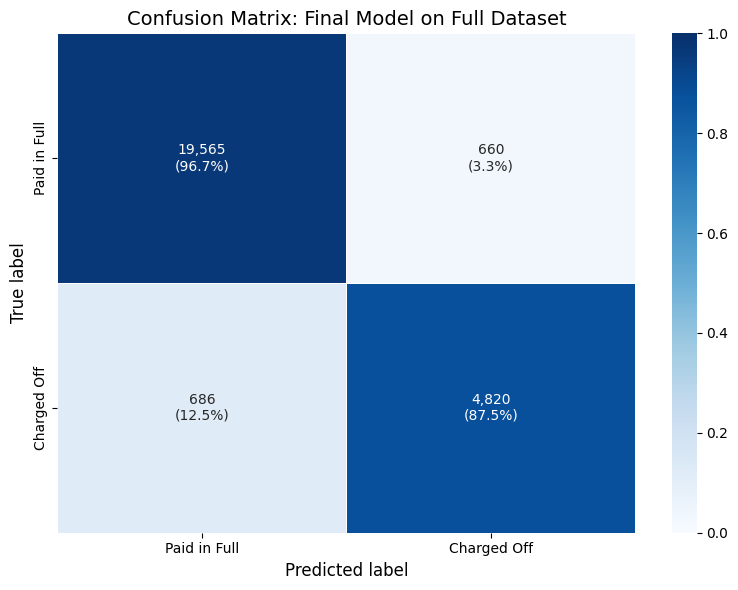

              precision    recall  f1-score   support

Paid in Full       0.97      0.97      0.97     20225
 Charged Off       0.88      0.88      0.88      5506

    accuracy                           0.95     25731
   macro avg       0.92      0.92      0.92     25731
weighted avg       0.95      0.95      0.95     25731



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Define and train the final model on the training set
final_model = XGBClassifier(
    eval_metric='logloss',
    subsample=0.8,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    gamma=5,
    colsample_bytree=0.8,
    random_state=42
)
final_model.fit(X_train, y_train)

# 2. Predict on ALL data (full X, not just test set)
y_pred_all = final_model.predict(X)

# 3. Build confusion matrix against all true labels
cm = confusion_matrix(y, y_pred_all)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = ['Paid in Full', 'Charged Off']
annot = np.array([
    [f"{cm[i,j]:,}\n({cm_norm[i,j]:.1%})" for j in range(2)]
    for i in range(2)
])

# 4. Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('Predicted label', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title('Confusion Matrix: Final Model on Full Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# 5. Full classification report
print(classification_report(y, y_pred_all, target_names=labels))

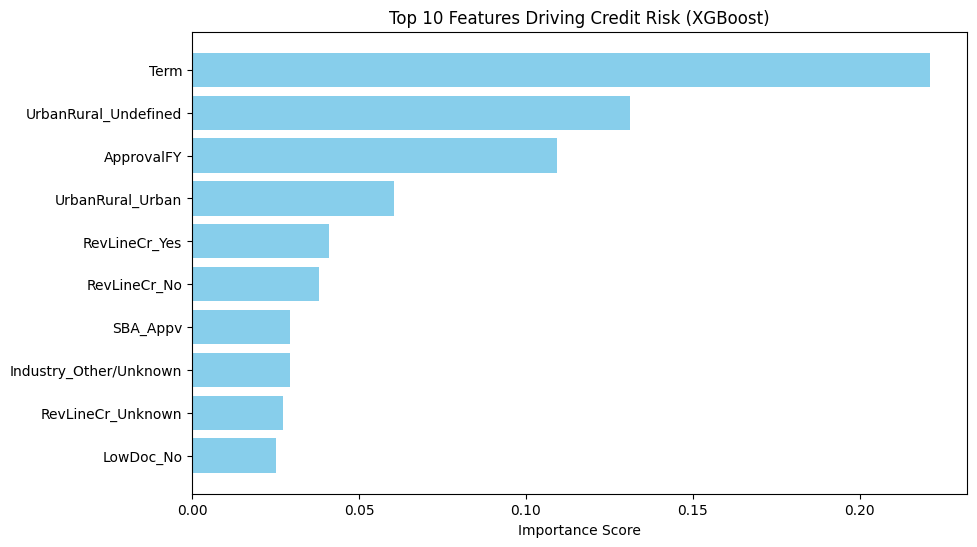

                   Feature  Importance
2                     Term    0.221136
12    UrbanRural_Undefined    0.131196
0               ApprovalFY    0.109475
13        UrbanRural_Urban    0.060501
16           RevLineCr_Yes    0.041163
14            RevLineCr_No    0.037887
7                 SBA_Appv    0.029471
33  Industry_Other/Unknown    0.029421
15       RevLineCr_Unknown    0.027222
17               LowDoc_No    0.024989


In [ ]:
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
# Based on best parameters found above, create final xgboost model
final_model = XGBClassifier(eval_metric='logloss',
                                    subsample = 0.8,
                                    n_estimators = 100,
                                    max_depth = 6,
                                    learning_rate = 0.1,
                                    gamma = 5,
                                    colsample_bytree = 0.8,
                                    random_state = 42)
# Fit model
final_model.fit(X_train, y_train)  # ← ADD THIS LINE
y_pred_final = final_model.predict(X_test)
# Get feature importance from the model
importances = final_model.feature_importances_
feature_names = X_train.columns
# Create a DataFrame for easy sorting and plotting
feature_insight = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_insight = feature_insight.sort_values(by='Importance', ascending=False)
# Plot the top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_insight['Feature'].head(10), feature_insight['Importance'].head(10), color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features Driving Credit Risk (XGBoost)')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()
# Print the table
print(feature_insight.head(10))

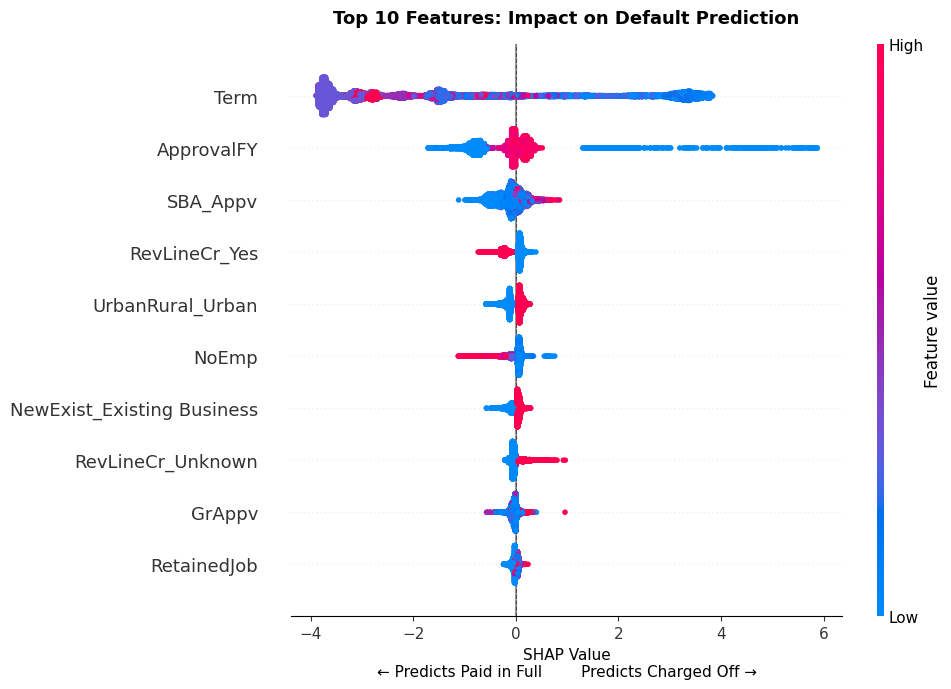

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Get SHAP values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# 2. Find top 10 features by mean absolute SHAP value
top10_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-10:]
top10_features = X_test.columns[top10_idx]

# 3. Filter SHAP values and data to top 10 only
shap_top10 = shap_values[:, top10_idx]
X_top10 = X_test[top10_features]

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_top10,
    X_top10,
    plot_type="dot",
    plot_size=None,     # disables auto-resizing so our figsize applies
    show=False
)

ax = plt.gca()
ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=11)
ax.set_title("Top 10 Features: Impact on Default Prediction", fontsize=13, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

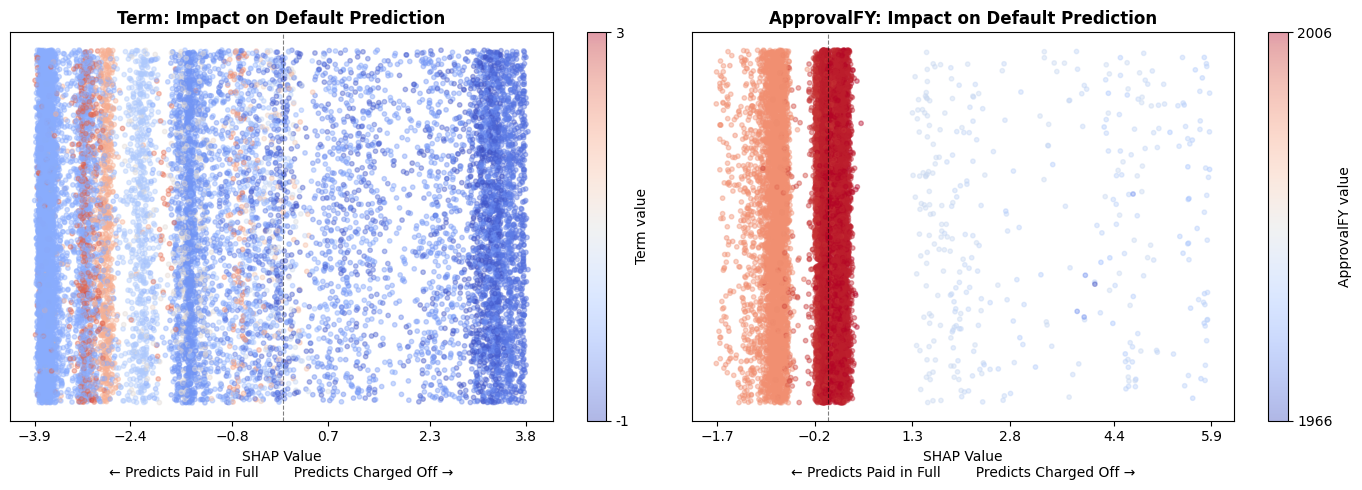

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature in zip(axes, ['Term', 'ApprovalFY']):
    feat_idx = X_test.columns.get_loc(feature)
    shap_feat = shap_values[:, feat_idx]
    feat_vals = X_test[feature].values

    scatter = ax.scatter(
        shap_feat,
        np.random.uniform(-0.3, 0.3, size=len(shap_feat)),  # jitter on y-axis
        c=feat_vals,
        cmap='coolwarm',
        alpha=0.4,
        s=10
    )

    # Colorbar showing actual feature values
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(f'{feature} value', fontsize=10)

    # Add actual min/max tick labels on colorbar
    cbar.set_ticks([feat_vals.min(), feat_vals.max()])
    cbar.set_ticklabels([f'{int(feat_vals.min())}', f'{int(feat_vals.max())}'])

    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_yticks([])
    ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=10)
    ax.set_title(f'{feature}: Impact on Default Prediction', fontsize=12, fontweight='bold')

    # Annotate min/max SHAP range on x-axis
    ax.set_xticks(np.round(np.linspace(shap_feat.min(), shap_feat.max(), 6), 1))

plt.tight_layout()
plt.show()

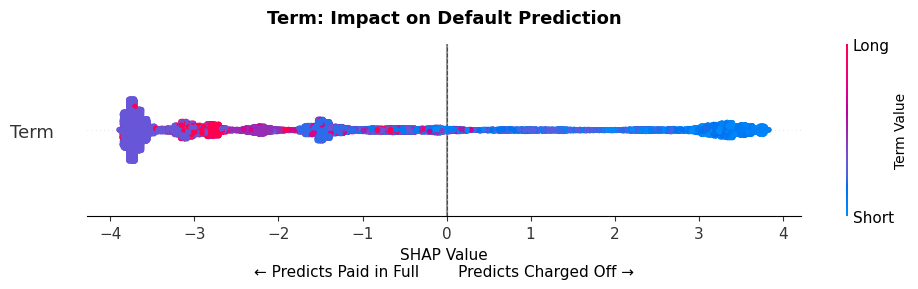

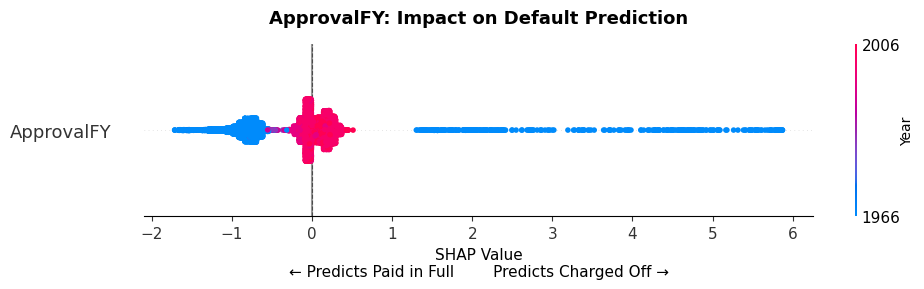

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Define friendly labels and min/max for each feature
feature_info = {
    'Term':       {'label': 'Term Value',    'min': 'Short', 'max': 'Long'},
    'ApprovalFY': {'label': 'Year',          'min': int(X_test['ApprovalFY'].min()), 'max': int(X_test['ApprovalFY'].max())}
}

for feature in ['Term', 'ApprovalFY']:
    feat_idx = X_test.columns.get_loc(feature)
    info = feature_info[feature]

    fig, ax = plt.subplots(figsize=(10, 3))
    shap.summary_plot(
        shap_values[:, feat_idx].reshape(-1, 1),
        X_test[[feature]],
        plot_type="dot",
        plot_size=None,
        show=False
    )

    ax = plt.gca()
    ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=11)
    ax.set_title(f'{feature}: Impact on Default Prediction', fontsize=13, fontweight='bold', pad=15)
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Update colorbar with feature-specific label and min/max tick labels
    cbar_ax = plt.gcf().axes[-1]
    cbar_ax.set_ylabel(info['label'], fontsize=10)
    cbar_min, cbar_max = cbar_ax.get_ylim()
    cbar_ax.yaxis.set_ticks([cbar_min, cbar_max])
    cbar_ax.set_yticklabels([str(info['min']), str(info['max'])])

    plt.tight_layout()
    plt.show()

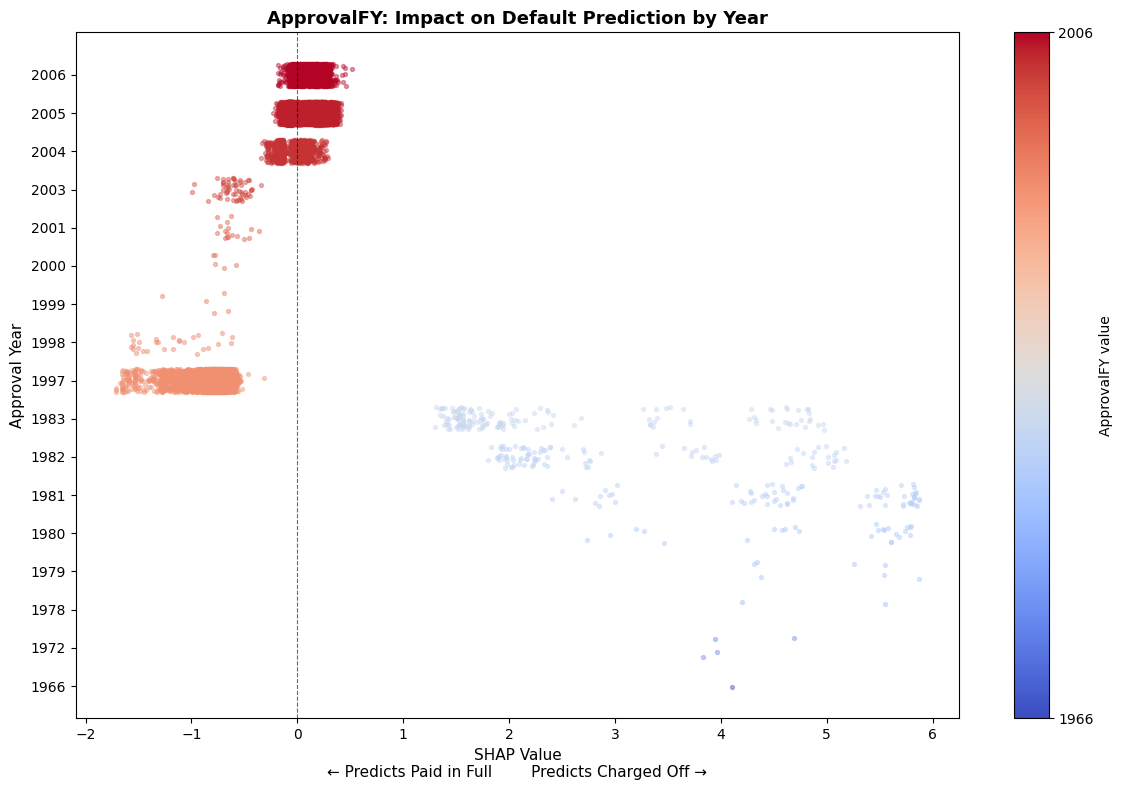

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

feat_idx = X_test.columns.get_loc('ApprovalFY')
shap_feat = shap_values[:, feat_idx]
feat_vals = X_test['ApprovalFY'].values

df_shap = pd.DataFrame({'shap': shap_feat, 'year': feat_vals})
years = sorted(df_shap['year'].unique())

# Normalize year values to 0-1 for colormap
norm = plt.Normalize(feat_vals.min(), feat_vals.max())
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(figsize=(12, 8))

for i, year in enumerate(years):
    subset = df_shap[df_shap['year'] == year]['shap']
    y_jitter = np.random.uniform(i - 0.3, i + 0.3, size=len(subset))
    color = cmap(norm(year))  # color based on year value low=blue, high=red
    ax.scatter(subset, y_jitter, color=color, alpha=0.4, s=8)

# Add colorbar showing low/high year
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('ApprovalFY value', fontsize=10)
cbar.set_ticks([feat_vals.min(), feat_vals.max()])
cbar.set_ticklabels([str(int(feat_vals.min())), str(int(feat_vals.max()))])

ax.set_yticks(range(len(years)))
ax.set_yticklabels([str(int(y)) for y in years], fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel("SHAP Value\n← Predicts Paid in Full        Predicts Charged Off →", fontsize=11)
ax.set_ylabel("Approval Year", fontsize=11)
ax.set_title("ApprovalFY: Impact on Default Prediction by Year", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()